# Classification of ECG Beats via CNN + Transformer

In [18]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import classification_report, accuracy_score, f1_score, roc_curve, auc

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

%matplotlib inline

## Prepare Data

In [4]:
TRAIN_PATH = "data/raw/mitbih_train.csv"
TEST_PATH = "data/raw/mitbih_test.csv"

def load_mitbih(fpath, split_name):

    # Load raw data
    df = pd.read_csv(fpath, header=None)

    # Count
    n_features = df.shape[1] - 1

    # Stable arbitrary ID: split + row index
    df["instance_id"] = [f"{split_name}_{i}" for i in range(len(df))]

    # Fix column names
    df.columns = [f"x{i}" for i in range(n_features)] + ["label"] + ["instance_id"]

    return df

# Load train and test data files
train_df = load_mitbih(TRAIN_PATH, "train")
test_df = load_mitbih(TEST_PATH, "test")

# Separate waveforms and labels
X_train = train_df.drop(columns=["label","instance_id"]).values.astype(np.float32)
y_train = train_df["label"].values

X_test = test_df.drop(columns=["label","instance_id"]).values.astype(np.float32)
y_test = test_df["label"].values

# Encode labels
encoder = LabelEncoder()
y_train = encoder.fit_transform(y_train)
y_test = encoder.transform(y_test)

# Define train and validation split (keep test set asis)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train,
    test_size=0.30,
    stratify=y_train,
    random_state=2026
)

# Reformat arrays for modeling

## CNN: (batch, channels, seq_len)
X_train_cnn = X_train[:, np.newaxis, :]
X_val_cnn = X_val[:, np.newaxis, :]
X_test_cnn = X_test[:, np.newaxis, :]

## Transformer: (batch, seq_len, features)
X_train_tf = X_train[:, :, np.newaxis]
X_val_tf = X_val[:, :, np.newaxis]
X_test_tf = X_test[:, :, np.newaxis]

# Save arrays
np.savez_compressed(
    "data/intermediate/ecg_splits.npz",

    # Flat waveforms
    X_train=X_train,
    X_val=X_val,
    X_test=X_test,

    # CNN-ready waveforms
    X_train_cnn=X_train_cnn,
    X_val_cnn=X_val_cnn,
    X_test_cnn=X_test_cnn,

    # Transformer-ready waveforms
    X_train_tf=X_train_tf,
    X_val_tf=X_val_tf,
    X_test_tf=X_test_tf,

    # Class labels
    y_train=y_train,
    y_val=y_val,
    y_test=y_test,

    # Metadata
    class_names=encoder.classes_
)

print("Saved processed data to: data/intermediate/ecg_splits.npz")
print()
print("Flat:")
print("  X_train:", X_train.shape)
print("  X_val:  ", X_val.shape)
print("  X_test: ", X_test.shape)
print()
print("CNN:")
print("  X_train_cnn:", X_train_cnn.shape)
print("  X_val_cnn:  ", X_val_cnn.shape)
print("  X_test_cnn: ", X_test_cnn.shape)
print()
print("Transformer:")
print("  X_train_tf:", X_train_tf.shape)
print("  X_val_tf:  ", X_val_tf.shape)
print("  X_test_tf: ", X_test_tf.shape)
print()
print("Classes:", list(encoder.classes_))


/var/folders/s_/l4dd894n6qg3xk_w50rc8qjw0000gn/T/ipykernel_17405/2542735919.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["instance_id"] = [f"{split_name}_{i}" for i in range(len(df))]


Saved processed data to: data/intermediate/ecg_splits.npz

Flat:
  X_train: (61287, 187)
  X_val:   (26267, 187)
  X_test:  (21892, 187)

CNN:
  X_train_cnn: (61287, 1, 187)
  X_val_cnn:   (26267, 1, 187)
  X_test_cnn:  (21892, 1, 187)

Transformer:
  X_train_tf: (61287, 187, 1)
  X_val_tf:   (26267, 187, 1)
  X_test_tf:  (21892, 187, 1)

Classes: [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0)]


## Fit Model

### CNN

In [8]:
DATA_PATH = "data/intermediate/ecg_splits.npz"
BATCH_SIZE = 128
EPOCHS = 20
LEARNING_RATE = 1e-3
RANDOM_STATE = 2026

if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")

print("Using device:", DEVICE)

torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

# Load CNN numpy arrays
data = np.load(DATA_PATH, allow_pickle=True)

X_train = data["X_train_cnn"] # shape: (n, 1, 187)
X_val = data["X_val_cnn"]
X_test = data["X_test_cnn"]

y_train = data["y_train"] # shape: (n,)
y_val = data["y_val"]
y_test = data["y_test"]

class_names = data["class_names"]
num_classes = len(class_names)

print("Training data shape:", X_train.shape)
print("Validation data shape:", X_val.shape)
print("Test data shape:", X_test.shape)
print("Classes:", class_names)

# Define Dataset and DataLoader
class ECGDataset(Dataset):

    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = ECGDataset(X_train, y_train)
val_dataset = ECGDataset(X_val, y_val)
test_dataset = ECGDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Define ECGCNN model class
class ECGCNN(nn.Module):
    
    def __init__(self, num_classes):
        
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=7, padding=3),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),   # 128 -> 64

            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),   # 64 -> 32

            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(2),   # 32 -> 16

            nn.Conv1d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)   # -> (batch, 187, 1)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# Instantiate model
model = ECGCNN(num_classes=num_classes).to(DEVICE)

# Loss / optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Train / evaluate functions
def run_epoch(model, loader, criterion, optimizer=None):
    training = optimizer is not None
    model.train() if training else model.eval()

    total_loss = 0.0
    all_preds = []
    all_true = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)

        if training:
            optimizer.zero_grad()

        with torch.set_grad_enabled(training):
            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            if training:
                loss.backward()
                optimizer.step()

        total_loss += loss.item() * X_batch.size(0)
        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_true.extend(y_batch.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_true, all_preds)
    macro_f1 = f1_score(all_true, all_preds, average="macro")

    return avg_loss, acc, macro_f1, all_true, all_preds

# Training loop
best_val_f1 = 0.0
best_model_state = None

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc, train_f1, _, _ = run_epoch(
        model, train_loader, criterion, optimizer
    )
    val_loss, val_acc, val_f1, _, _ = run_epoch(
        model, val_loader, criterion
    )

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Train F1: {train_f1:.4f} | "
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}"
    )

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_model_state = model.state_dict()

# Load best model
if best_model_state is not None:
    model.load_state_dict(best_model_state)

# Test evaluation
test_loss, test_acc, test_f1, y_true, y_pred = run_epoch(
    model, test_loader, criterion
)

print("\nTest results")
print(f"Loss: {test_loss:.4f}")
print(f"Accuracy: {test_acc:.4f}")
print(f"Macro F1: {test_f1:.4f}")

print("\nClassification Report")
class_names = [str(x) for x in data["class_names"]]
print(classification_report(y_true, y_pred, target_names=class_names))

Using device: mps
Training data shape: (61287, 1, 187)
Validation data shape: (26267, 1, 187)
Test data shape: (21892, 1, 187)
Classes: [0. 1. 2. 3. 4.]
Epoch 01/20 | Train Loss: 0.2654 | Train Acc: 0.9264 | Train F1: 0.5490 | Val Loss: 0.1543 | Val Acc: 0.9587 | Val F1: 0.6834
Epoch 02/20 | Train Loss: 0.1461 | Train Acc: 0.9614 | Train F1: 0.6907 | Val Loss: 0.1414 | Val Acc: 0.9628 | Val F1: 0.7348
Epoch 03/20 | Train Loss: 0.1205 | Train Acc: 0.9674 | Train F1: 0.7864 | Val Loss: 0.1281 | Val Acc: 0.9617 | Val F1: 0.7227
Epoch 04/20 | Train Loss: 0.1073 | Train Acc: 0.9706 | Train F1: 0.8258 | Val Loss: 0.0942 | Val Acc: 0.9737 | Val F1: 0.8684
Epoch 05/20 | Train Loss: 0.0970 | Train Acc: 0.9741 | Train F1: 0.8505 | Val Loss: 0.0944 | Val Acc: 0.9730 | Val F1: 0.8555
Epoch 06/20 | Train Loss: 0.0898 | Train Acc: 0.9753 | Train F1: 0.8601 | Val Loss: 0.0924 | Val Acc: 0.9734 | Val F1: 0.8645
Epoch 07/20 | Train Loss: 0.0846 | Train Acc: 0.9769 | Train F1: 0.8679 | Val Loss: 0.0870 

In [12]:
def plot_roc_curves_cnn(
    model,
    X_test,
    y_test,
    class_names=None,
    device="cpu",
    batch_size=256,
    title="CNN ROC Curves",
    show_micro=True,
    show_macro=True,
):
    """
    Plot ROC curves for a PyTorch classification model.

    Parameters
    ----------
    model : torch.nn.Module
        Trained CNN model.
    X_test : np.ndarray
        Test features, shape (n_samples, channels, seq_len) for CNN.
    y_test : array-like
        True class labels as integers.
    class_names : list[str], optional
        Names for each class, in label index order.
    device : str or torch.device
        Device for inference.
    batch_size : int
        Batch size for prediction.
    title : str
        Plot title.
    show_micro : bool
        Whether to show micro-average ROC for multiclass.
    show_macro : bool
        Whether to show macro-average ROC for multiclass.
    """
    model.eval()
    device = torch.device(device)

    # -----------------
    # Get predicted probabilities
    # -----------------
    X_tensor = torch.tensor(X_test, dtype=torch.float32)
    probs_list = []

    with torch.no_grad():
        for start in range(0, len(X_tensor), batch_size):
            X_batch = X_tensor[start:start + batch_size].to(device)
            logits = model(X_batch)
            probs = torch.softmax(logits, dim=1)
            probs_list.append(probs.cpu().numpy())

    scores = np.vstack(probs_list)   # shape: (n_samples, n_classes)

    y = np.asarray(y_test)
    classes = np.unique(y)
    n_classes = len(classes)

    if class_names is None:
        class_names = [str(c) for c in classes]
    else:
        class_names = [str(c) for c in class_names]

    plt.figure(figsize=(8, 6))
    plt.title(title)

    # -----------------
    # Binary case
    # -----------------
    if n_classes == 2:
        y_score = scores[:, 1]
        y_true = (y == classes[1]).astype(int)

        fpr, tpr, _ = roc_curve(y_true, y_score)
        roc_auc = auc(fpr, tpr)

        plt.plot(fpr, tpr, label=f"ROC (AUC={roc_auc:.4f})")
        plt.plot([0, 1], [0, 1], linestyle="--")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.legend(loc="lower right")
        plt.tight_layout()
        plt.show()
        return

    # -----------------
    # Multiclass case (OvR)
    # -----------------
    y_bin = label_binarize(y, classes=classes)

    if scores.ndim != 2 or scores.shape[1] != n_classes:
        raise ValueError(
            f"Expected scores of shape (n_samples, n_classes). "
            f"Got {scores.shape}."
        )

    fpr_dict = {}
    tpr_dict = {}
    auc_dict = {}

    for i in range(n_classes):
        fpr_i, tpr_i, _ = roc_curve(y_bin[:, i], scores[:, i])
        fpr_dict[i] = fpr_i
        tpr_dict[i] = tpr_i
        auc_dict[i] = auc(fpr_i, tpr_i)

        plt.plot(fpr_i, tpr_i, label=f"{class_names[i]} (AUC={auc_dict[i]:.4f})")

    if show_micro:
        fpr_micro, tpr_micro, _ = roc_curve(y_bin.ravel(), scores.ravel())
        auc_micro = auc(fpr_micro, tpr_micro)
        plt.plot(
            fpr_micro,
            tpr_micro,
            linestyle="--",
            label=f"micro-average (AUC={auc_micro:.4f})"
        )

    if show_macro:
        all_fpr = np.unique(np.concatenate([fpr_dict[i] for i in range(n_classes)]))
        mean_tpr = np.zeros_like(all_fpr)

        for i in range(n_classes):
            mean_tpr += np.interp(all_fpr, fpr_dict[i], tpr_dict[i])

        mean_tpr /= n_classes
        auc_macro = auc(all_fpr, mean_tpr)

        plt.plot(
            all_fpr,
            mean_tpr,
            linestyle="--",
            label=f"macro-average (AUC={auc_macro:.4f})"
        )

    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend(loc="lower right", fontsize=8)
    plt.tight_layout()
    plt.show()

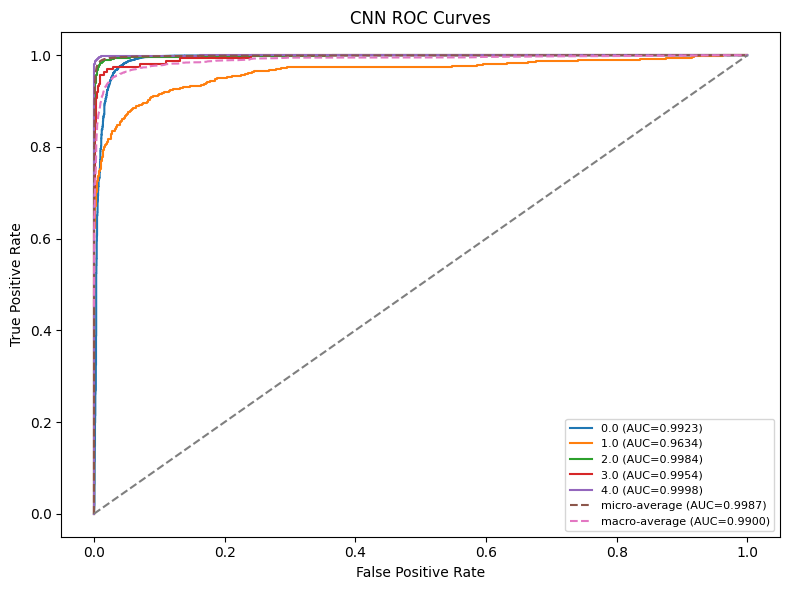

In [13]:
plot_roc_curves_cnn(
    model=model,
    X_test=X_test,
    y_test=y_test,
    class_names=class_names,
    device=DEVICE,
    title="CNN ROC Curves"
)

### Transformer

In [32]:
# Load train/val/test waveforms for transformer
X_train = data["X_train_tf"] # shape: (n, 187, 1)
X_val = data["X_val_tf"]
X_test = data["X_test_tf"]

print("Training data shape:", X_train.shape)
print("Validation data shape:", X_val.shape)
print("Test data shape:", X_test.shape)
print("Classes:", class_names)

# Define Dataset and DataLoader
class ECGDataset(Dataset):

    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = ECGDataset(X_train, y_train)
val_dataset = ECGDataset(X_val, y_val)
test_dataset = ECGDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

Training data shape: (61287, 187, 1)
Validation data shape: (26267, 187, 1)
Test data shape: (21892, 187, 1)
Classes: [0. 1. 2. 3. 4.]


In [33]:
class PositionalEncoding(nn.Module):

    def __init__(self, d_model, max_len=500):

        super().__init__()

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)

        div_term = torch.exp(
            torch.arange(0, d_model, 2, dtype=torch.float32)
            * (-math.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)  # shape: (1, max_len, d_model)
        self.register_buffer("pe", pe)

    def forward(self, x):
        # x shape: (batch, seq_len, d_model)
        seq_len = x.size(1)
        return x + self.pe[:, :seq_len, :]


class ECGTransformer(nn.Module):
    
    def __init__(
        self,
        num_classes,
        seq_len=187,
        input_dim=1,
        d_model=64,
        nhead=4,
        num_layers=2,
        dim_feedforward=128,
        dropout=0.1,
    ):
        super().__init__()

        self.input_projection = nn.Linear(input_dim, d_model)
        self.positional_encoding = PositionalEncoding(d_model=d_model, max_len=seq_len)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
            activation="gelu",
        )

        self.encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers,
        )

        self.classifier = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        # x shape: (batch, seq_len, 1)
        x = self.input_projection(x)          # (batch, seq_len, d_model)
        x = self.positional_encoding(x)       # (batch, seq_len, d_model)
        x = self.encoder(x)                   # (batch, seq_len, d_model)

        # global average pooling across sequence length
        x = x.mean(dim=1)                     # (batch, d_model)

        x = self.classifier(x)                # (batch, num_classes)
        return x

In [34]:
# Instantiate transformer model
seq_len = X_train.shape[1]
num_classes = len(class_names)

tf_model = ECGTransformer(
    num_classes=num_classes,
    seq_len=seq_len
).to(DEVICE)

In [36]:
# Loss / optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(tf_model.parameters(), lr=LEARNING_RATE)

# Train / evaluate functions
def run_epoch(model, loader, criterion, optimizer=None):
    training = optimizer is not None
    model.train() if training else model.eval()

    total_loss = 0.0
    all_preds = []
    all_true = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)

        if training:
            optimizer.zero_grad()

        with torch.set_grad_enabled(training):
            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            if training:
                loss.backward()
                optimizer.step()

        total_loss += loss.item() * X_batch.size(0)
        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_true.extend(y_batch.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_true, all_preds)
    macro_f1 = f1_score(all_true, all_preds, average="macro")

    return avg_loss, acc, macro_f1, all_true, all_preds

# Training loop
best_val_f1 = 0.0
best_model_state = None

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc, train_f1, _, _ = run_epoch(
        tf_model, train_loader, criterion, optimizer
    )
    val_loss, val_acc, val_f1, _, _ = run_epoch(
        tf_model, val_loader, criterion
    )

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Train F1: {train_f1:.4f} | "
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}"
    )

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_model_state = tf_model.state_dict()

# Load best model
if best_model_state is not None:
    tf_model.load_state_dict(best_model_state)

# Test evaluation
test_loss, test_acc, test_f1, y_true, y_pred = run_epoch(
    tf_model, test_loader, criterion
)

print("\nTest results")
print(f"Loss: {test_loss:.4f}")
print(f"Accuracy: {test_acc:.4f}")
print(f"Macro F1: {test_f1:.4f}")

print("\nClassification Report")
class_names = [str(x) for x in data["class_names"]]
print(classification_report(y_true, y_pred, target_names=class_names))

Epoch 01/20 | Train Loss: 0.1802 | Train Acc: 0.9522 | Train F1: 0.7291 | Val Loss: 0.1571 | Val Acc: 0.9554 | Val F1: 0.7589
Epoch 02/20 | Train Loss: 0.1572 | Train Acc: 0.9578 | Train F1: 0.7813 | Val Loss: 0.1316 | Val Acc: 0.9619 | Val F1: 0.8119
Epoch 03/20 | Train Loss: 0.1414 | Train Acc: 0.9621 | Train F1: 0.8087 | Val Loss: 0.1247 | Val Acc: 0.9635 | Val F1: 0.8034
Epoch 04/20 | Train Loss: 0.1295 | Train Acc: 0.9638 | Train F1: 0.8154 | Val Loss: 0.1149 | Val Acc: 0.9676 | Val F1: 0.8502
Epoch 05/20 | Train Loss: 0.1186 | Train Acc: 0.9661 | Train F1: 0.8284 | Val Loss: 0.1114 | Val Acc: 0.9698 | Val F1: 0.8393
Epoch 06/20 | Train Loss: 0.1128 | Train Acc: 0.9682 | Train F1: 0.8456 | Val Loss: 0.1030 | Val Acc: 0.9711 | Val F1: 0.8762
Epoch 07/20 | Train Loss: 0.1041 | Train Acc: 0.9699 | Train F1: 0.8495 | Val Loss: 0.0932 | Val Acc: 0.9729 | Val F1: 0.8756
Epoch 08/20 | Train Loss: 0.0993 | Train Acc: 0.9717 | Train F1: 0.8569 | Val Loss: 0.0937 | Val Acc: 0.9730 | Val F1:

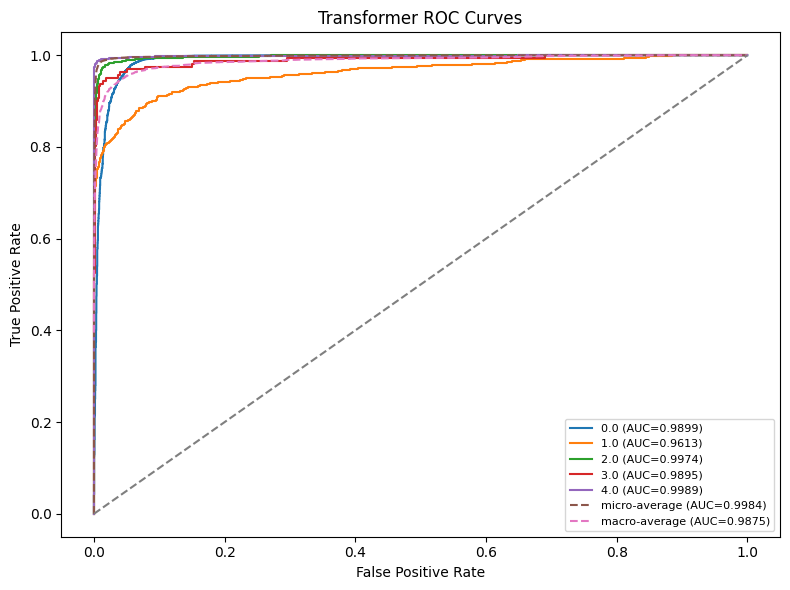

In [37]:
plot_roc_curves_cnn(
    model=tf_model,
    X_test=X_test,
    y_test=y_test,
    class_names=class_names,
    device=DEVICE,
    title="Transformer ROC Curves"
)